In [1]:
from collections import defaultdict
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np
import xarray as xr
from context_flux_no.metrics import relative_L2_error, relative_L_infty_error
from context_flux_no.training.io import load_model
from einops import rearrange
from more_itertools import one
from tqdm import tqdm


datadir = Path("../../data")
checkpoint_dir = Path("../../checkpoints")

jax.config.update("jax_default_device", jax.devices("gpu")[0])

In [2]:
@eqx.filter_jit
def compute_metrics(model, u, args, context_length=20):
    context, u_data = u[:context_length], u[context_length:]

    u_pred = model.rollout(context, args, num_steps=len(u_data))[0]

    return {
        "l2_onestep": relative_L2_error(u_pred[0], u_data[0]),
        "l_inf_onestep": relative_L_infty_error(u_pred[0], u_data[0]),
        "l2_rollout": relative_L2_error(u_pred, u_data),
        "l_inf_rollout": relative_L_infty_error(u_pred, u_data),
    }


## In-distribution results

In [3]:
dataset_test = xr.open_dataset(
    datadir / "datasets/burgers_1d/data/test/burgers_1d_test_grf_seed=10.hdf5",
    engine="h5netcdf",
    chunks={},
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = dataset_test["values"].values
segments = np.lib.stride_tricks.sliding_window_view(values, 40, axis=1)
segments = rearrange(segments, "batch t0 c x t -> (batch t0) t c x")
segments.shape

(620000, 40, 1, 100)

In [ ]:
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])
results_dict = defaultdict(list)
for model_type in ("DPOT", "HyperFluxFNOLocal", "DISCO"):
    for seed in tqdm((0, 10, 20)):
        model_dir = (
            checkpoint_dir / "burgers_1d" / model_type / "OneStepLoss" / f"seed={seed}"
        )
        model = load_model(one(model_dir.iterdir()))
        model = eqx.nn.inference_mode(model, True)
        results = jax.lax.map(
            eqx.filter_jit(lambda u: compute_metrics(model, u, (dt, dx))),
            segments,
            batch_size=1500,
        )
        print(jax.tree.map(lambda x: x.shape, results))
        results_dict[model_type].append(jax.tree.map(jnp.mean, results))

 33%|███▎      | 1/3 [03:08<06:16, 188.49s/it]

{'l2_onestep': (620000,), 'l2_rollout': (620000,), 'l_inf_onestep': (620000,), 'l_inf_rollout': (620000,)}


 67%|██████▋   | 2/3 [06:06<03:02, 182.19s/it]

{'l2_onestep': (620000,), 'l2_rollout': (620000,), 'l_inf_onestep': (620000,), 'l_inf_rollout': (620000,)}


100%|██████████| 3/3 [09:04<00:00, 181.41s/it]


...

{'l2_onestep': (620000,), 'l2_rollout': (620000,), 'l_inf_onestep': (620000,), 'l_inf_rollout': (620000,)}


 67%|██████▋   | 2/3 [43:41<21:43, 1303.44s/it]

{'l2_onestep': (620000,), 'l2_rollout': (620000,), 'l_inf_onestep': (620000,), 'l_inf_rollout': (620000,)}


100%|██████████| 3/3 [1:08:55<00:00, 1378.54s/it]

{'l2_onestep': (620000,), 'l2_rollout': (620000,), 'l_inf_onestep': (620000,), 'l_inf_rollout': (620000,)}


In [5]:
import json


with open("../../data/analysis/burgers_indistribution.json", "w") as f:
    json.dump(jax.tree.map(lambda x: float(x), results_dict), f)

In [ ]:
for model_name, res in results_dict.items():
    res_ = jax.tree.transpose(jax.tree.structure(["*"] * 3), None, res)
    print(
        model_name,
        jax.tree.map(
            lambda list_: {
                "mean": jnp.mean(jnp.asarray(list_)),
                "std": jnp.std(jnp.asarray(list_)),
            },
            res_,
            is_leaf=lambda x: isinstance(x, list),
        ),
    )

DPOT {'l2_onestep': {'mean': Array(0.00262629, dtype=float32), 'std': Array(2.925365e-06, dtype=float32)}, 'l2_rollout': {'mean': Array(0.04659583, dtype=float32), 'std': Array(0.00107259, dtype=float32)}, 'l_inf_onestep': {'mean': Array(0.00716978, dtype=float32), 'std': Array(4.2893083e-05, dtype=float32)}, 'l_inf_rollout': {'mean': Array(0.15645465, dtype=float32), 'std': Array(0.00438519, dtype=float32)}}
HyperFluxFNOLocal {'l2_onestep': {'mean': Array(0.00132385, dtype=float32), 'std': Array(2.8978617e-05, dtype=float32)}, 'l2_rollout': {'mean': Array(0.01717408, dtype=float32), 'std': Array(0.00023508, dtype=float32)}, 'l_inf_onestep': {'mean': Array(0.00343673, dtype=float32), 'std': Array(7.303022e-05, dtype=float32)}, 'l_inf_rollout': {'mean': Array(0.06455672, dtype=float32), 'std': Array(0.00065081, dtype=float32)}}
DISCO {'l2_onestep': {'mean': Array(0.00343079, dtype=float32), 'std': Array(0.00020939, dtype=float32)}, 'l2_rollout': {'mean': Array(0.06562701, dtype=float32)

: 

## OOD results

In [3]:
dataset_test = xr.open_dataset(
    datadir / "datasets/burgers_1d/data/test/burgers_1d_test_step_seed=10.hdf5",
    engine="h5netcdf",
    chunks={},
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = dataset_test["values"].values
segments = np.lib.stride_tricks.sliding_window_view(values, 40, axis=1)
segments = rearrange(segments, "batch t0 c x t -> (batch t0) t c x")
segments.shape

(620000, 40, 1, 100)

In [4]:
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])
results_dict = defaultdict(list)
for model_type in ("DPOT", "HyperFluxFNOLocal", "DISCO"):
    for seed in tqdm((0, 10, 20)):
        model_dir = (
            checkpoint_dir / "burgers_1d" / model_type / "OneStepLoss" / f"seed={seed}"
        )
        model = load_model(one(model_dir.iterdir()))
        model = eqx.nn.inference_mode(model, True)
        results = jax.lax.map(
            eqx.filter_jit(lambda u: compute_metrics(model, u, (dt, dx))),
            segments,
            batch_size=4000,
        )
        print(jax.tree.map(lambda x: x.shape, results))
        results_dict[model_type].append(jax.tree.map(jnp.mean, results))

  0%|          | 0/3 [00:00<?, ?it/s]

{'l2_onestep': (620000,), 'l2_rollout': (620000,), 'l_inf_onestep': (620000,), 'l_inf_rollout': (620000,)}


 67%|██████▋   | 2/3 [07:02<03:30, 210.65s/it]

{'l2_onestep': (620000,), 'l2_rollout': (620000,), 'l_inf_onestep': (620000,), 'l_inf_rollout': (620000,)}


100%|██████████| 3/3 [10:30<00:00, 210.17s/it]


...

{'l2_onestep': (620000,), 'l2_rollout': (620000,), 'l_inf_onestep': (620000,), 'l_inf_rollout': (620000,)}


 67%|██████▋   | 2/3 [51:34<25:57, 1557.09s/it]

{'l2_onestep': (620000,), 'l2_rollout': (620000,), 'l_inf_onestep': (620000,), 'l_inf_rollout': (620000,)}


100%|██████████| 3/3 [1:13:38<00:00, 1472.84s/it]

{'l2_onestep': (620000,), 'l2_rollout': (620000,), 'l_inf_onestep': (620000,), 'l_inf_rollout': (620000,)}


import json


with open("../../data/analysis/burgers_ood_step.json", "w") as f:
    json.dump(jax.tree.map(lambda x: float(x), results_dict), f)

In [ ]:
import json


with open("../../data/analysis/burgers_ood_step.json", "r") as f:
    results_dict = json.load(f)

In [4]:
for model_name, res in results_dict.items():
    res_ = jax.tree.transpose(jax.tree.structure(["*"] * 3), None, res)
    print(
        model_name,
        jax.tree.map(
            lambda list_: {
                "mean": jnp.mean(jnp.asarray(list_)),
                "std": jnp.std(jnp.asarray(list_)),
            },
            res_,
            is_leaf=lambda x: isinstance(x, list),
        ),
    )

DISCO {'l2_onestep': {'mean': Array(0.00273193, dtype=float32), 'std': Array(9.7418124e-05, dtype=float32)}, 'l2_rollout': {'mean': Array(0.04526646, dtype=float32), 'std': Array(0.01414384, dtype=float32)}, 'l_inf_onestep': {'mean': Array(0.00757983, dtype=float32), 'std': Array(0.00042355, dtype=float32)}, 'l_inf_rollout': {'mean': Array(0.24114671, dtype=float32), 'std': Array(0.12487223, dtype=float32)}}
DPOT {'l2_onestep': {'mean': Array(0.00188881, dtype=float32), 'std': Array(2.1005626e-05, dtype=float32)}, 'l2_rollout': {'mean': Array(0.0450381, dtype=float32), 'std': Array(0.00319041, dtype=float32)}, 'l_inf_onestep': {'mean': Array(0.00507614, dtype=float32), 'std': Array(0.00016739, dtype=float32)}, 'l_inf_rollout': {'mean': Array(0.17844144, dtype=float32), 'std': Array(0.01165023, dtype=float32)}}
HyperFluxFNOLocal {'l2_onestep': {'mean': Array(0.00164978, dtype=float32), 'std': Array(2.4271074e-05, dtype=float32)}, 'l2_rollout': {'mean': Array(0.02206653, dtype=float32), 

## Long time

In [3]:
@eqx.filter_jit
def metrics_long_rollout(model, u, args, context_length=20):
    context, u_data = u[:context_length], u[context_length:]
    u_pred = model.rollout(context, args, num_steps=len(u_data))[0]
    l2 = jax.vmap(relative_L2_error)(u_pred, u_data)
    l_inf = jax.vmap(relative_L_infty_error)(u_pred, u_data)
    return {"l2": l2, "l_inf": l_inf}

In [4]:
dataset_test = xr.open_dataset(
    datadir / "datasets/burgers_1d/data/test/burgers_1d_test_grf_seed=10.hdf5",
    engine="h5netcdf",
    chunks={},
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = dataset_test["values"].values

In [ ]:
results_dict = defaultdict(list)
for model_type in ("DPOT", "HyperFluxFNOLocal", "DISCO"):
    for seed in tqdm((0, 10, 20)):
        model_dir = (
            checkpoint_dir / "burgers_1d" / model_type / "OneStepLoss" / f"seed={seed}"
        )
        model = load_model(one(model_dir.iterdir()))
        model = eqx.nn.inference_mode(model, True)
        results = jax.lax.map(
            eqx.filter_jit(lambda u: metrics_long_rollout(model, u, (dt, dx))),
            values,
            batch_size=1000,
        )
        print(jax.tree.map(lambda x: x.shape, results))
        results_dict[model_type].append(results)


 33%|███▎      | 1/3 [00:19<00:39, 19.88s/it]

{'l2': (10000, 81), 'l_inf': (10000, 81)}


 67%|██████▋   | 2/3 [00:33<00:16, 16.41s/it]

{'l2': (10000, 81), 'l_inf': (10000, 81)}


100%|██████████| 3/3 [00:47<00:00, 15.92s/it]


...

{'l2': (10000, 81), 'l_inf': (10000, 81)}


 67%|██████▋   | 2/3 [04:21<02:06, 126.87s/it]

{'l2': (10000, 81), 'l_inf': (10000, 81)}


100%|██████████| 3/3 [06:15<00:00, 125.23s/it]

{'l2': (10000, 81), 'l_inf': (10000, 81)}


In [6]:
results_stacked = {
    k: jax.tree.transpose(
        jax.tree.structure(["*"] * 3),
        None,
        v,
    )
    for k, v in results_dict.items()
}
results_stacked = jax.tree.map(
    np.stack, results_stacked, is_leaf=lambda x: isinstance(x, list)
)

with h5py.File("../../data/analysis/burgers_1d_long_rollout.hdf5", "w") as f:
    for model_name, res_dict in results_stacked.items():
        g = f.create_group(model_name)
        for metric_name, val in res_dict.items():
            g.create_dataset(metric_name, data=val)

In [2]:
dataset_test = xr.open_dataset(
    datadir / "datasets/burgers_1d/data/test/burgers_1d_test_step_seed=10.hdf5",
    engine="h5netcdf",
    chunks={},
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = dataset_test["values"].values


u_pred_dict = {}
seed = 20
traj_idx = 5
for model_type in ("DPOT", "HyperFluxFNOLocal", "DISCO"):
    model_dir = (
        checkpoint_dir / "burgers_1d" / model_type / "OneStepLoss" / f"seed={seed}"
    )
    model = load_model(one(model_dir.iterdir()))
    model = eqx.nn.inference_mode(model, True)
    context, u_data = values[traj_idx, :20], values[traj_idx, 20:]
    u_pred = model.rollout(context, (dt, dx), num_steps=len(u_data))[0]

    u_pred_dict[model_type] = u_pred

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/encoders/utils.py:50: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:40: UserWarning: out_features is not divisible by num_blocks. Output vector 
            will be truncated to the requested size.
  warnings.warn("""out_features is not divisible by num_blocks. Output vector
E0504 19:59:49.103865  882387 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.11 = f32[64,500]{1,0} fusion(get-tuple-element.96, bitcast.1111), kind=kCustom, calls=gemm_fusion_dot.11_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["128","256"]}],"num_ctas":1,"num_stages":4,"is

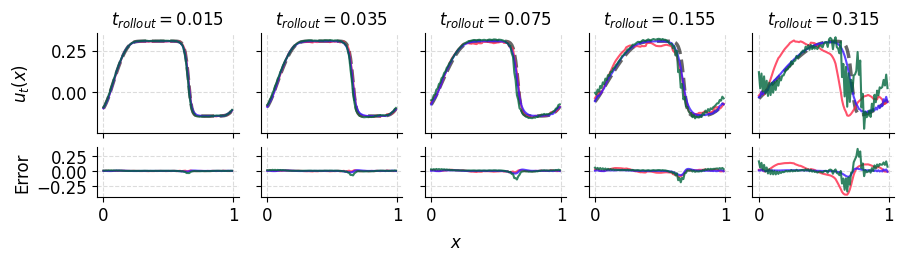

In [ ]:
import colorcet as cc
import matplotlib.pyplot as plt


plt.style.use("context_flux_no.plotting.styles.dash_gridded")

COLOR_DICT = {
    "DPOT": cc.cm.glasbey_bw(85),
    "ICON": cc.cm.glasbey_bw(1),
    "DISCO": cc.cm.glasbey_bw(68),
    "HyperFluxFNOLocal": cc.cm.glasbey_bw(41),
}

LABEL_DICT = {
    "DPOT": "DPOT",
    "ICON": "ICON",
    "DISCO": "DISCO",
    "HyperFluxFNOLocal": "HFluxNO (Ours)",
}

fig, axes = plt.subplots(
    2,
    5,
    figsize=(9, 2.5),
    constrained_layout=True,
    sharex=True,
    sharey="row",
    height_ratios=(2, 1),
)
for i in range(axes.shape[1]):
    t_idx = 4 * 2**i - 1
    axes[0, i].plot(
        dataset_test.x,
        u_data[t_idx, 0],
        label="Data",
        color="black",
        linewidth=2.5,
        ls="--",
        alpha=0.6,
    )
    for model_type, u_pred in u_pred_dict.items():
        axes[0, i].plot(
            dataset_test.x,
            u_pred[t_idx, 0],
            label=LABEL_DICT[model_type],
            color=COLOR_DICT[model_type],
            linewidth=1.5,
            alpha=0.8,
        )
        axes[1, i].plot(
            dataset_test.x,
            u_pred[t_idx, 0] - u_data[t_idx, 0],
            label=LABEL_DICT[model_type],
            color=COLOR_DICT[model_type],
            linewidth=1.5,
            alpha=0.8,
        )
        axes[0, i].set_title("$t_{rollout}=$" + f"${t_idx * dt}$", fontsize="medium")
        # axes[0, i].text(0.4, -1.2, )
fig.supxlabel("$x$", fontsize="medium")
axes[0, 0].set_ylabel("$u_t(x)$")
axes[1, 0].set_ylabel("Error")
fig.align_ylabels()
fig.savefig("../../figures/fig2/rollout_trajectory_burgers_step.pdf", dpi=500)

## High resolution

In [3]:
dataset_test = xr.open_dataset(
    datadir / "datasets/burgers_1d/data/test/burgers_1d_test_grf_hires_seed=10.hdf5",
    engine="h5netcdf",
    chunks={},
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = dataset_test["values"].values
values.shape

(10000, 101, 1, 400)

In [38]:
u_pred_dict = {}
downsample = 2
seed = 0
traj_idx = 100
for model_type in ("HyperFluxFNOLocal", "DISCO"):
    model_dir = (
        checkpoint_dir / "burgers_1d" / model_type / "OneStepLoss" / f"seed={seed}"
    )
    model = load_model(one(model_dir.iterdir()))
    model = eqx.nn.inference_mode(model, True)
    context, u_data = (
        values[traj_idx, :20, :, ::downsample],
        values[traj_idx, 20:, :, ::downsample],
    )
    u_pred = model.rollout(context, (dt, dx * downsample), num_steps=len(u_data))[0]

    u_pred_dict[model_type] = u_pred

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/encoders/utils.py:50: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:40: UserWarning: out_features is not divisible by num_blocks. Output vector 
            will be truncated to the requested size.
  warnings.warn("""out_features is not divisible by num_blocks. Output vector


(20, 2, 100)


/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


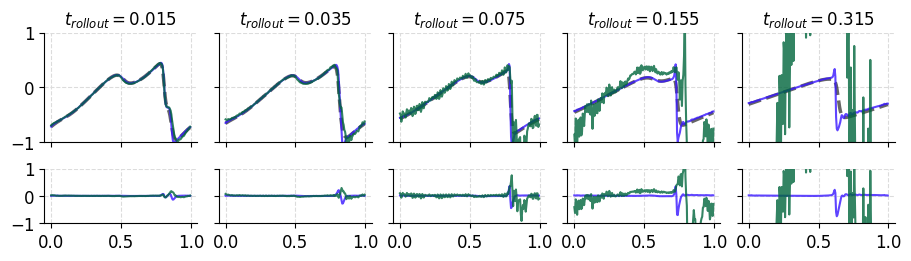

In [39]:
import colorcet as cc
import matplotlib.pyplot as plt


plt.style.use("context_flux_no.plotting.styles.dash_gridded")

COLOR_DICT = {
    "DPOT": cc.cm.glasbey_bw(85),
    "ICON": cc.cm.glasbey_bw(1),
    "DISCO": cc.cm.glasbey_bw(68),
    "HyperFluxFNOLocal": cc.cm.glasbey_bw(41),
}

LABEL_DICT = {
    "DPOT": "DPOT",
    "ICON": "ICON",
    "DISCO": "DISCO",
    "HyperFluxFNOLocal": "HFluxNO (Ours)",
}

fig, axes = plt.subplots(
    2,
    5,
    figsize=(9, 2.5),
    constrained_layout=True,
    sharex=True,
    sharey="row",
    height_ratios=(2, 1),
)
for i in range(axes.shape[1]):
    t_idx = 4 * 2**i - 1
    axes[0, i].plot(
        dataset_test.x[::downsample],
        u_data[t_idx, 0],
        label="Data",
        color="black",
        linewidth=2.5,
        ls="--",
        alpha=0.6,
    )
    for model_type, u_pred in u_pred_dict.items():
        axes[0, i].plot(
            dataset_test.x[::downsample],
            u_pred[t_idx, 0],
            label=LABEL_DICT[model_type],
            color=COLOR_DICT[model_type],
            linewidth=1.5,
            alpha=0.8,
        )
        axes[1, i].plot(
            dataset_test.x[::downsample],
            u_pred[t_idx, 0] - u_data[t_idx, 0],
            label=LABEL_DICT[model_type],
            color=COLOR_DICT[model_type],
            linewidth=1.5,
            alpha=0.8,
        )
        axes[0, i].set_title("$t_{rollout}=$" + f"${t_idx * dt}$", fontsize="medium")
    axes[0, i].set_ylim((-1, 1))
    axes[1, i].set_ylim((-1, 1))
    # axes[0, i].text(0.4, -1.2, )